# Multimodal coupling — do the modalities work together?

The cross-modal **rank correlation heatmap** in notebooks 01/02 shows almost
nothing between gesture and voice (|rho| ~ 0.03-0.07), which sits badly against
a qualitative literature in which gesture, prosody and speech are understood to
make meaning *jointly*. This notebook exists to test whether that null is a
finding about the speakers or an artefact of how the question was asked.

**The short version of the argument.** The heatmap correlates *5-second means*.
Gesture-speech coupling lives at **0.2-2 seconds** — the stroke lands on the
pitch accent, the beat on the stressed syllable. Averaging over 5s destroys
phase relationships, and correlating magnitudes tests "do faster hands come
with higher pitch", which is not what the literature claims. Both things can be
true: perfect moment-to-moment coordination, zero correlation of window means.

Each section below is one candidate figure, with what it can and cannot show.
They are deliberately independent — run the ones that earn their place and
delete the rest.

| # | figure | what it demonstrates | data it needs |
|---|---|---|---|
| 1 | within- vs between-speaker decomposition | whether the null hides speaker-level structure | stored windows |
| 2 | window-lag cross-correlation + null band | coupling at 5-25s lags, with a proper null | stored windows |
| 3 | time-varying coupling | that coupling is *intermittent*, not absent | stored windows |
| 4 | event-aligned average | gesture around prosodic peaks | stored windows |
| 5 | mutual information vs Spearman | nonlinear dependence Spearman cannot see | stored windows |
| 6 | categorical association (chi-square / Cramér's V) | production choices against delivery choices | stored windows |
| 7 | confound checks | speaker, duration and shot scale as common causes | stored windows |
| 8 | multimodal timeline (excerpt) | qualitative alignment, gesture vs words | dense keyframes + tokens |
| 9 | sub-second cross-correlation | **the real test** of gesture-speech synchrony | dense prosody ✓ |

Figure 9 is the one that actually answers the question, and it now runs: the
dense f0 and intensity contours it needs are stored for all 39 Ted videos
(`scripts/backfill_dense_prosody.py`). Every flat line in sections 2-5 was
explicable by 5-second averaging; section 9 is the first figure here that can
distinguish "no coupling" from "coupling we cannot see".

**Both branches of §6 are covered.** Sections 1-5 and 9 take the continuous
branch (Spearman, mutual information, cross-correlation); section 6 takes the
categorical one (chi-square, Cramér's V) that the specification asks for by
name; section 7 works through its confound list. Gesture is body-normalised
throughout, which §6 sets as the precondition for running any of this.

In [1]:
import sys, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore", category=RuntimeWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

import _corpus as C

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})

CORPUS = "Ted"          # "Ted" or "YiXi"
WINDOW_S = 5.0           # window size these results were produced with

# load_corpus rather than load_windows: §6 opens by requiring that
# "normalization of frequency and structural dynamics must be resolved before
# running this analysis", and the normalised columns live here — body-scaled
# gesture (wrist_speed_mean), speaker-relative pitch (pitch_st) and the
# per-speaker tertiles the categorical section needs.
data = C.load_corpus(CORPUS)
df, videos = data.windows, data.videos
HAS_DATA = not df.empty
print(f"{CORPUS}: {len(df)} windows, {df.job_id.nunique()} videos")
C.coverage_report(df).head(12)

/home/abx13/Prog/Mannerism-Analyzer/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



loading TedX: 0/4 |          | 


loading TedX: 0/4 |          | , cache hit


loading TedX: 4/4 |██████████| , cache hit


loading TedX: 4/4 |██████████| , cache hit

loaded from cache: /tmp/mannerism/corpus_cache/TedX_d7c2f39825cd755a.pkl
TedX: 6013 windows, 39 videos


,non_null,total,coverage
wrist_speed_p90,5576,6013,0.927
wrist_speed_max,5576,6013,0.927
n_samples,5576,6013,0.927
wrist_speed_mean,5576,6013,0.927
max_wrist_displacement,5661,6013,0.941
handedness_ratio,5661,6013,0.941
mean_wrist_velocity,5661,6013,0.941
vertical_angle,5661,6013,0.941
horizontal_angle,5661,6013,0.941
mean_face_pitch_deg,5661,6013,0.941


## The pair under test

Everything below uses one gesture signal and one prosody signal, so the figures
are comparable. Swap them here rather than in each cell.

`mean_intensity_db` is the better prosody choice than `mean_f0`: pooled across
speakers, mean pitch largely encodes *who is talking* (vocal-tract physiology),
whereas intensity varies within a speaker with emphasis.

**Gesture is body-normalised now**, which is the precondition §6 opens with —
"normalization of frequency and structural dynamics must be resolved before
running this analysis". `wrist_speed_mean` is wrist displacement over the
speaker's own shoulder width and torso height, in shoulder-widths per second.
The stored `mean_wrist_velocity` is pixels per second and correlates with
`mean_face_bbox_area` at ~0.47 in Ted, so any coupling measured with it is
partly a correlation with how close the camera happens to be. Notebook 01
section 4 has the confound check; the earlier version of this notebook used the
pixel signal and its figures were weaker for it.

In [2]:
GESTURE = "wrist_speed_mean"       # shoulder-widths/s, not pixels/s
PROSODY = "mean_intensity_db"

pair = df[["job_id", "window_idx", "start_s", GESTURE, PROSODY, "word_count"]].dropna()
print(f"{len(pair)} windows with both signals, {pair.job_id.nunique()} videos")

# The pixel signal is kept only for the contrast in section 7's confound table.
PIXEL_GESTURE = "mean_wrist_velocity"

5576 windows with both signals, 39 videos


## 1. Within- vs between-speaker decomposition

A pooled correlation blends two different questions: whether a speaker gestures
more *when* they are louder (within), and whether speakers who gesture more are
*generally* louder (between). They can point in opposite directions, and a
pooled zero can hide either.

**How to read it.** Each dot is one video's own Spearman correlation. The
vertical line at zero is the null; the diamond is the pooled estimate; the
square is the between-speaker correlation of per-video means.

**What it rules out.** If the dots scatter tightly around zero, the null is not
an averaging artefact across speakers — no individual speaker shows the effect
either.

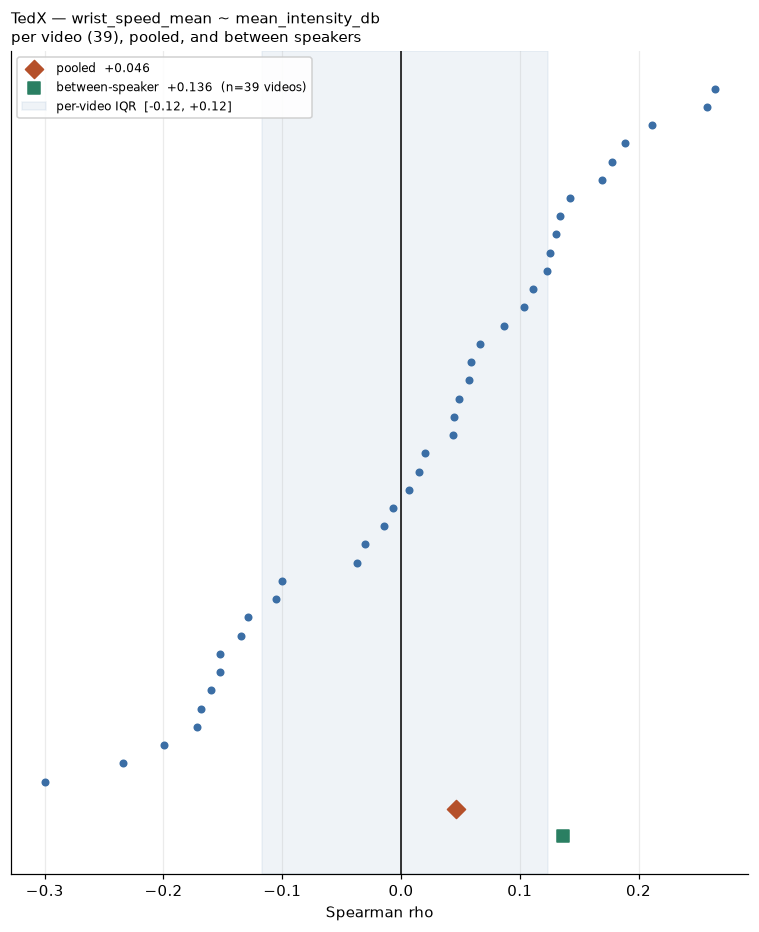

per-video median +0.044   min -0.300   max +0.264


In [3]:
if HAS_DATA:
    per_video, n_used = [], 0
    for jid, g in pair.groupby("job_id"):
        if len(g) > 30 and g[GESTURE].nunique() > 5 and g[PROSODY].nunique() > 5:
            rho = spearmanr(g[GESTURE], g[PROSODY]).statistic
            if not np.isnan(rho):
                per_video.append((jid, rho, len(g)))
                n_used += 1
    pv = pd.DataFrame(per_video, columns=["job_id", "rho", "n"]).sort_values("rho")
    pooled = spearmanr(pair[GESTURE], pair[PROSODY]).statistic
    vm = pair.groupby("job_id")[[GESTURE, PROSODY]].mean().dropna()
    between = spearmanr(vm[GESTURE], vm[PROSODY]).statistic

    fig, ax = plt.subplots(figsize=(7, max(3, 0.22 * len(pv))))
    ax.scatter(pv.rho, range(len(pv)), s=18, color="#3b6ea5", zorder=3)
    ax.axvline(0, color="k", lw=1)
    ax.scatter([pooled], [-1.5], marker="D", s=70, color="#b5502a", zorder=4,
               label=f"pooled  {pooled:+.3f}")
    ax.scatter([between], [-3.0], marker="s", s=70, color="#2a7f62", zorder=4,
               label=f"between-speaker  {between:+.3f}  (n={len(vm)} videos)")
    ax.axvspan(pv.rho.quantile(.25), pv.rho.quantile(.75), color="#3b6ea5", alpha=0.08,
               label=f"per-video IQR  [{pv.rho.quantile(.25):+.2f}, {pv.rho.quantile(.75):+.2f}]")
    ax.set_yticks([]); ax.set_xlabel("Spearman rho")
    ax.set_title(f"{CORPUS} — {GESTURE} ~ {PROSODY}\nper video ({n_used}), pooled, and between speakers", loc="left", fontsize=10)
    ax.legend(loc="upper left", fontsize=8, framealpha=0.9)
    plt.tight_layout(); plt.show()
    print(f"per-video median {pv.rho.median():+.3f}   min {pv.rho.min():+.3f}   max {pv.rho.max():+.3f}")

## 2. Window-lag cross-correlation, with a permutation null

Correlation at lag 0 is one number out of a family: gesture may lead or trail
speech. This plots rho against lag, in windows (so +1 = 5 seconds).

**The null band is not optional.** Both series are strongly autocorrelated —
loud windows cluster, gesture bursts cluster — so *any* two such series show
non-zero cross-correlation. The grey band is the 2.5-97.5 percentile of the
same statistic computed on **circularly shifted** data (shifting preserves each
signal's own autocorrelation while destroying the cross-relationship). Only
excursions outside that band mean anything.

**What it cannot show.** The resolution floor is one window = 5s. Gesture-speech
synchrony happens an order of magnitude faster. A flat line here is *expected*
even if the speakers are perfectly coordinated — see section 7.

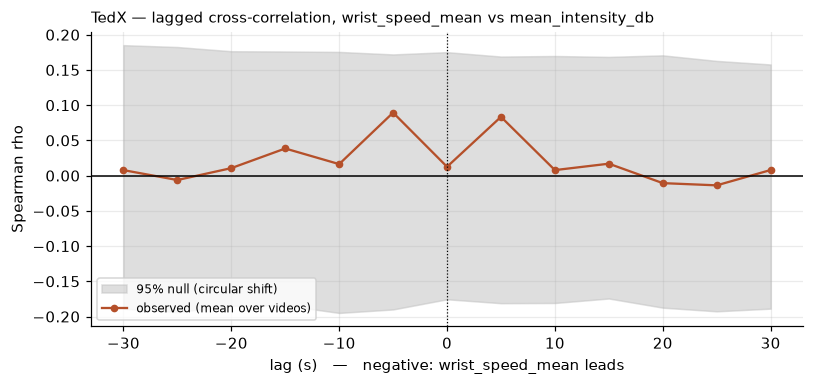

lags outside the null band: none


In [4]:
MAX_LAG = 6          # windows; +/- 30s at WINDOW_S = 5
N_PERM = 500

def lagged_rho(a, b, lag):
    if lag > 0:   a, b = a[:-lag], b[lag:]
    elif lag < 0: a, b = a[-lag:], b[:lag]
    if len(a) < 20: return np.nan
    return spearmanr(a, b).statistic

if HAS_DATA:
    lags = np.arange(-MAX_LAG, MAX_LAG + 1)
    obs = {l: [] for l in lags}
    null = {l: [] for l in lags}
    rng = np.random.default_rng(0)

    for jid, g in pair.groupby("job_id"):
        g = g.sort_values("window_idx")
        a, b = g[GESTURE].to_numpy(), g[PROSODY].to_numpy()
        if len(a) < 40:
            continue
        for l in lags:
            obs[l].append(lagged_rho(a, b, l))
        for _ in range(N_PERM // 10):                # 50 shifts per video
            shift = rng.integers(10, len(b) - 10)
            bs = np.roll(b, shift)
            for l in lags:
                null[l].append(lagged_rho(a, bs, l))

    mean_obs = np.array([np.nanmean(obs[l]) for l in lags])
    lo = np.array([np.nanpercentile(null[l], 2.5) for l in lags])
    hi = np.array([np.nanpercentile(null[l], 97.5) for l in lags])

    fig, ax = plt.subplots(figsize=(7.5, 3.6))
    ax.fill_between(lags * WINDOW_S, lo, hi, color="0.75", alpha=0.5,
                    label="95% null (circular shift)")
    ax.plot(lags * WINDOW_S, mean_obs, "-o", ms=4, color="#b5502a", label="observed (mean over videos)")
    ax.axhline(0, color="k", lw=1); ax.axvline(0, color="k", lw=0.8, ls=":")
    ax.set_xlabel(f"lag (s)   —   negative: {GESTURE} leads")
    ax.set_ylabel("Spearman rho")
    ax.set_title(f"{CORPUS} — lagged cross-correlation, {GESTURE} vs {PROSODY}", loc="left", fontsize=10)
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

    outside = [(l * WINDOW_S, m) for l, m, a_, b_ in zip(lags, mean_obs, lo, hi) if not (a_ <= m <= b_)]
    print("lags outside the null band:", outside or "none")

## 3. Time-varying coupling

A single corpus-wide number assumes coupling is stationary. It is not: speakers
gesture emphatically in bursts, and a mean over a whole talk averages those
bursts against long stretches of low-key delivery.

This computes a rolling correlation inside each video and plots it as a strip
per video (one row each, time on x). Red/blue bands mean coupling that comes
and goes.

**How to read it.** If the rows are uniformly pale, coupling really is absent at
this resolution. If they show strong alternating bands, the corpus-level zero is
an *average of opposing episodes*, which is a finding in itself — and it says
the right analysis is episodic, not global.

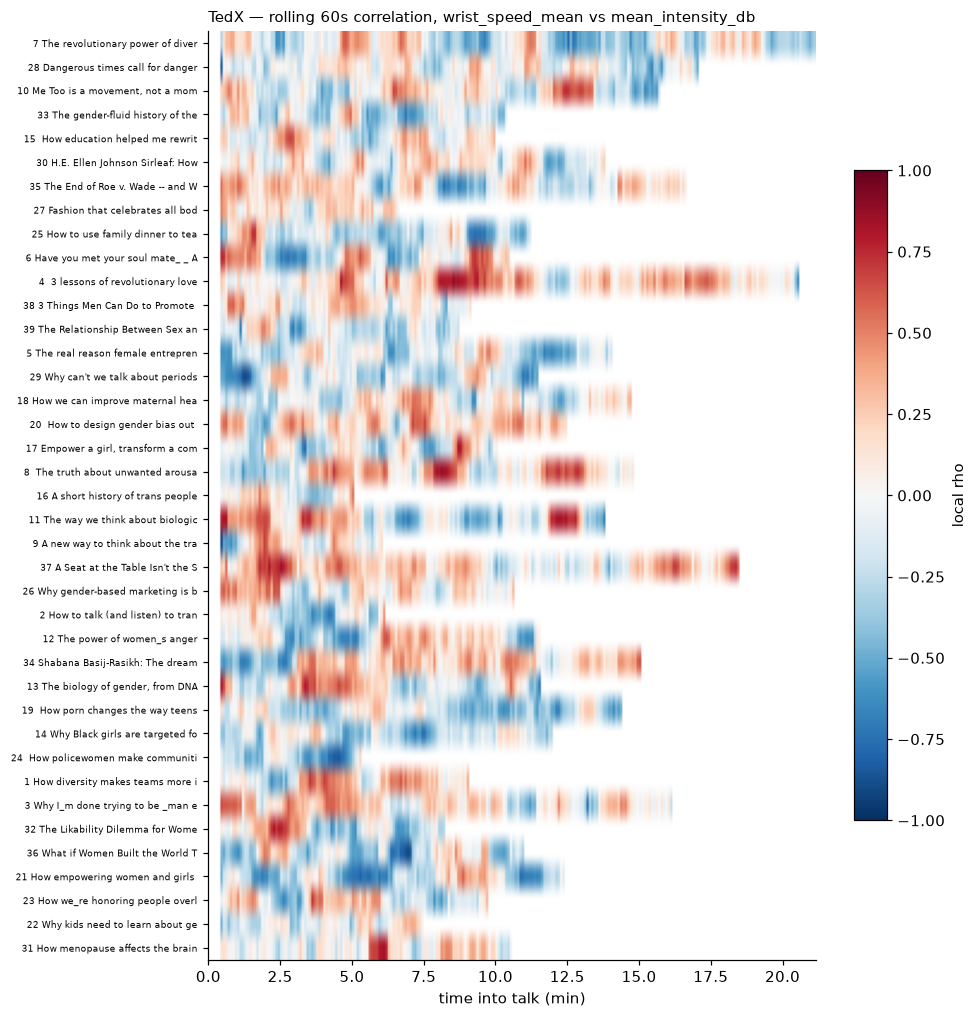

local rho: median +0.002, 19.8% of windows above +0.3, 21.3% below -0.3


In [5]:
ROLL = 12            # windows -> 60s at WINDOW_S = 5

if HAS_DATA:
    strips, labels = [], []
    for jid, g in pair.groupby("job_id"):
        g = g.sort_values("window_idx")
        if len(g) < ROLL * 2:
            continue
        # Rank within the video first, so the rolling Pearson correlation is a
        # rolling *Spearman* — consistent with every other figure here, and
        # robust to the outliers window-level gesture metrics carry.
        ga, pa = g[GESTURE].rank(), g[PROSODY].rank()
        r = ga.rolling(ROLL, min_periods=ROLL // 2).corr(pa)
        strips.append(r.to_numpy())
        lab = videos.loc[videos.job_id == jid, "label"]
        labels.append((lab.iloc[0] if len(lab) and isinstance(lab.iloc[0], str) else jid)[:34])

    width = max(len(s) for s in strips)
    mat = np.full((len(strips), width), np.nan)
    for i, s in enumerate(strips):
        mat[i, :len(s)] = s

    fig, ax = plt.subplots(figsize=(9, max(3, 0.24 * len(strips))))
    im = ax.imshow(mat, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1,
                   extent=[0, width * WINDOW_S / 60, len(strips), 0])
    ax.set_yticks(np.arange(len(labels)) + 0.5); ax.set_yticklabels(labels, fontsize=6)
    ax.set_xlabel("time into talk (min)"); ax.grid(False)
    ax.set_title(f"{CORPUS} — rolling {int(ROLL * WINDOW_S)}s correlation, {GESTURE} vs {PROSODY}", loc="left", fontsize=10)
    fig.colorbar(im, ax=ax, shrink=0.7, label="local rho")
    plt.tight_layout(); plt.show()

    flat = mat[~np.isnan(mat)]
    print(f"local rho: median {np.median(flat):+.3f}, "
          f"{100 * np.mean(flat > 0.3):.1f}% of windows above +0.3, "
          f"{100 * np.mean(flat < -0.3):.1f}% below -0.3")

## 4. Event-aligned average (peri-event)

Rather than correlating continuously, this asks a sharper question: **around
moments of vocal emphasis, does gesture rise?**

Events are windows in the top decile of `mean_intensity_db` *within each video*
(so a loud speaker does not dominate). Gesture is z-scored per video, then
averaged in a +/- 6-window neighbourhood around each event. The grey band is
the same average around randomly chosen windows.

**How to read it.** A bump at lag 0 rising above the band is direct evidence of
coordination, and it is far easier to read than a correlation coefficient. It is
also the figure closest to what qualitative coding describes.

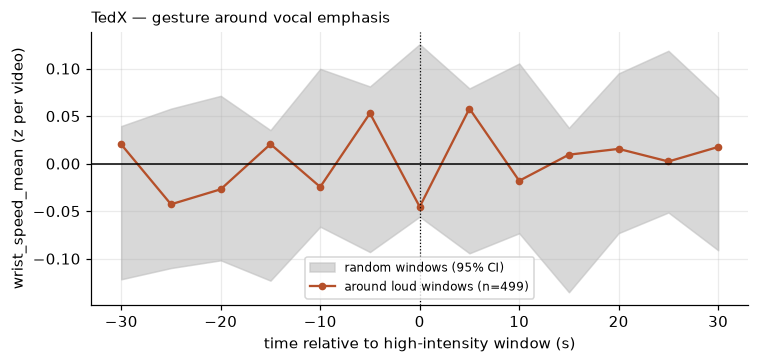

at lag 0: observed -0.045 vs null +0.035 +/- 0.091


In [6]:
HALF = 6
TOP_Q = 0.90

if HAS_DATA:
    rng = np.random.default_rng(1)
    obs_curves, null_curves = [], []
    for jid, g in pair.groupby("job_id"):
        g = g.sort_values("window_idx").reset_index(drop=True)
        if len(g) < 3 * HALF:
            continue
        z = (g[GESTURE] - g[GESTURE].mean()) / (g[GESTURE].std() or np.nan)
        thresh = g[PROSODY].quantile(TOP_Q)
        events = g.index[(g[PROSODY] >= thresh)].to_numpy()
        events = events[(events >= HALF) & (events < len(g) - HALF)]
        if len(events) == 0:
            continue
        obs_curves += [z.to_numpy()[e - HALF:e + HALF + 1] for e in events]
        fake = rng.integers(HALF, len(g) - HALF, size=len(events))
        null_curves += [z.to_numpy()[f - HALF:f + HALF + 1] for f in fake]

    obs_m = np.nanmean(np.vstack(obs_curves), axis=0)
    null_stack = np.vstack(null_curves)
    null_m = np.nanmean(null_stack, axis=0)
    null_sd = np.nanstd(null_stack, axis=0) / np.sqrt(len(null_stack))
    x = np.arange(-HALF, HALF + 1) * WINDOW_S

    fig, ax = plt.subplots(figsize=(7, 3.4))
    ax.fill_between(x, null_m - 1.96 * null_sd, null_m + 1.96 * null_sd,
                    color="0.75", alpha=0.6, label="random windows (95% CI)")
    ax.plot(x, obs_m, "-o", ms=4, color="#b5502a", label=f"around loud windows (n={len(obs_curves)})")
    ax.axvline(0, color="k", ls=":", lw=0.8); ax.axhline(0, color="k", lw=1)
    ax.set_xlabel("time relative to high-intensity window (s)")
    ax.set_ylabel(f"{GESTURE} (z per video)")
    ax.set_title(f"{CORPUS} — gesture around vocal emphasis", loc="left", fontsize=10)
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()
    print(f"at lag 0: observed {obs_m[HALF]:+.3f} vs null {null_m[HALF]:+.3f} "
          f"+/- {1.96 * null_sd[HALF]:.3f}")

## 5. Mutual information vs Spearman

Spearman detects **monotonic** association only. If gesture rises at both very
quiet and very loud moments (plausible: emphasis and hesitation), Spearman
returns ~0 while the variables are plainly dependent.

Mutual information makes no monotonicity assumption. It is not comparable in
scale to rho, so the two matrices are shown side by side: read them for
*disagreement*. A cell that is pale on the left and dark on the right is a
nonlinear relationship the original heatmap could not see.

MI is biased upward with small samples, so values are reported against a
shuffled baseline subtracted off.

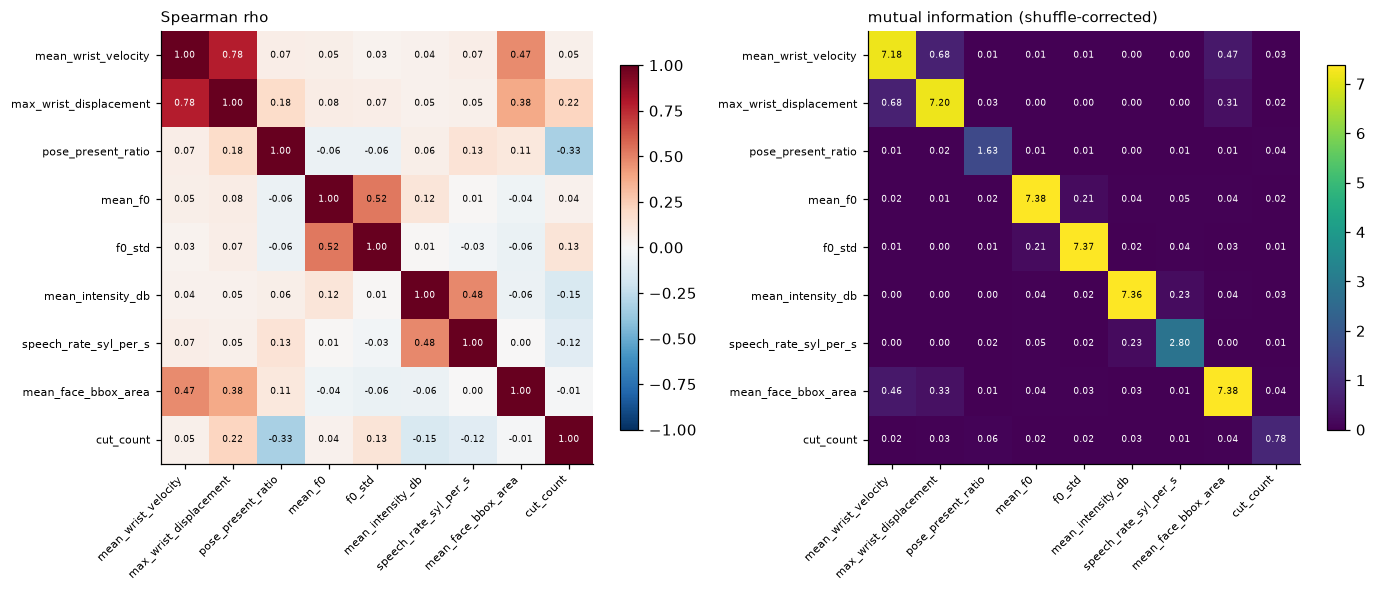

In [7]:
from sklearn.feature_selection import mutual_info_regression

COLS = [c for c in ["mean_wrist_velocity", "max_wrist_displacement", "pose_present_ratio",
                    "mean_f0", "f0_std", "mean_intensity_db", "speech_rate_syl_per_s",
                    "mean_face_bbox_area", "cut_count"]
        if c in df.columns and df[c].notna().sum() > 50]

if HAS_DATA:
    sub = df[COLS].dropna()
    rng = np.random.default_rng(2)
    n = len(COLS)
    mi = np.zeros((n, n)); rho = np.zeros((n, n))
    for i, a in enumerate(COLS):
        x = sub[[a]].to_numpy()
        raw = mutual_info_regression(x, sub[a], random_state=0)[0]
        for j, b in enumerate(COLS):
            m = mutual_info_regression(x, sub[b], random_state=0)[0]
            base = mutual_info_regression(x, rng.permutation(sub[b].to_numpy()), random_state=0)[0]
            mi[i, j] = max(0.0, m - base)
            rho[i, j] = spearmanr(sub[a], sub[b]).statistic

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
    for ax, mat, title, kw in (
        (axes[0], rho, "Spearman rho", dict(cmap="RdBu_r", vmin=-1, vmax=1)),
        (axes[1], mi, "mutual information (shuffle-corrected)", dict(cmap="viridis")),
    ):
        im = ax.imshow(mat, **kw)
        ax.set_xticks(range(n)); ax.set_xticklabels(COLS, rotation=45, ha="right", fontsize=7)
        ax.set_yticks(range(n)); ax.set_yticklabels(COLS, fontsize=7)
        ax.set_title(title, fontsize=10, loc="left"); ax.grid(False)
        for i in range(n):
            for j in range(n):
                ax.text(j, i, f"{mat[i, j]:.2f}", ha="center", va="center", fontsize=6,
                        color="white" if (kw.get("cmap") == "viridis" and mat[i, j] < mi.max() * 0.6)
                                          or (kw.get("cmap") == "RdBu_r" and abs(mat[i, j]) > 0.55) else "black")
        fig.colorbar(im, ax=ax, shrink=0.75)
    plt.tight_layout(); plt.show()

## 6. Categorical association — the other half of §6

Everything above treats the modalities as continuous and reaches for Spearman
or mutual information. §6 asks for both branches to be decided in advance:

> categorical variables (shot type, pitch bin, velocity bin) call for
> chi-square / Cramér's V; continuous variables ... call for point-biserial or
> Pearson/Spearman depending on distribution.

The categorical branch was missing, and it is not redundant. A continuous
correlation between gesture magnitude and intensity asks "do faster hands come
with a louder voice". The categorical version asks a different and more
CDA-shaped question: **does the editor cut to a close-up when the speaker is
doing something with their voice or hands?** That is an association between a
production choice and a delivery choice, and neither variable is continuous.

Bins are the per-speaker tertiles the flagging system already uses, so "high"
means high *for that speaker* and a loud talker does not fill the top bin on
their own. Shot type is categorical as stored.

**Cramér's V, not p.** These windows are not independent — a single shot spans
several — so chi-square's p-value is anti-conservative to the point of being
useless at this n. V is a proportion-of-association measure and is the number
to read; the per-video check that follows is the one whose n is honest.

In [8]:
from scipy.stats import chi2_contingency

def cramers_v(tab):
    chi2, p, dof, exp = chi2_contingency(tab)
    n = tab.values.sum()
    return chi2, p, dof, np.sqrt(chi2 / (n * (min(tab.shape) - 1))), exp

if HAS_DATA:
    cat = df.copy()
    # Gesture tertiles within speaker, matching how pitch_level and
    # pitch_variation were already built by _corpus.pitch_relative.
    cat["gesture_bin"] = (cat.groupby("job_id")[GESTURE]
                          .transform(lambda s: pd.qcut(s, 3,
                                                       labels=["low", "mid", "high"],
                                                       duplicates="drop")))
    PAIRS = [("dominant_shot_type", "gesture_bin"),
             ("dominant_shot_type", "pitch_level"),
             ("dominant_shot_type", "pitch_variation"),
             ("gesture_bin", "pitch_level"),
             ("gesture_bin", "pitch_variation")]

    rows = []
    for a, b in PAIRS:
        sub = cat[[a, b]].dropna()
        if sub.empty or sub[a].nunique() < 2 or sub[b].nunique() < 2:
            continue
        tab = pd.crosstab(sub[a], sub[b])
        chi2, pv, dof, v, exp = cramers_v(tab)
        rows.append({"variable A": a, "variable B": b, "n windows": int(tab.values.sum()),
                     "chi2": round(chi2, 1), "dof": dof, "Cramer's V": round(v, 3),
                     "strength": ("negligible" if v < 0.1 else "small" if v < 0.3
                                  else "moderate" if v < 0.5 else "large")})
    assoc = pd.DataFrame(rows)
    display(assoc.set_index(["variable A", "variable B"]))
    print("Cramer's V is the number to read. p-values are omitted deliberately: "
          "windows within a shot are not independent, so every pair here would "
          "read as p<1e-10 regardless of effect size.")

n windows   chi2  dof  Cramer's V  \
variable A         variable B                                           
dominant_shot_type gesture_bin           5576  267.5   12       0.155   
                   pitch_level           5636   16.0   12       0.038   
                   pitch_variation       5636   13.4   12       0.035   
gesture_bin        pitch_level           5553   44.6    4       0.063   
                   pitch_variation       5553   17.7    4       0.040   

                                      strength  
variable A         variable B                   
dominant_shot_type gesture_bin           small  
                   pitch_level      negligible  
                   pitch_variation  negligible  
gesture_bin        pitch_level      negligible  
                   pitch_variation  negligible

Cramer's V is the number to read. p-values are omitted deliberately: windows within a shot are not independent, so every pair here would read as p<1e-10 regardless of effect size.


### Which cells drive the strongest association

Standardised residuals for the pair with the largest V. Beyond ±2 marks a cell
occurring more (positive) or less (negative) often than independence predicts —
which is what turns "there is an association" into a statement about *what goes
with what*.

strongest association: dominant_shot_type x gesture_bin   Cramer's V = 0.155


gesture_bin,low %,mid %,high %,low resid,mid resid,high resid
dominant_shot_type,,,,,,
close_up,26.5,35.5,38.0,-6.5,2.2,4.3
extreme_close_up,0.0,20.4,79.6,-4.3,-1.6,5.9
long,38.9,32.0,29.1,3.1,-0.7,-2.5
medium,44.7,33.3,22.0,2.1,0.0,-2.2
medium_close,39.5,32.3,28.2,3.4,-0.5,-2.9
medium_long,31.7,34.1,34.1,-0.4,0.2,0.2
very_long,62.3,19.0,18.7,8.2,-4.0,-4.2


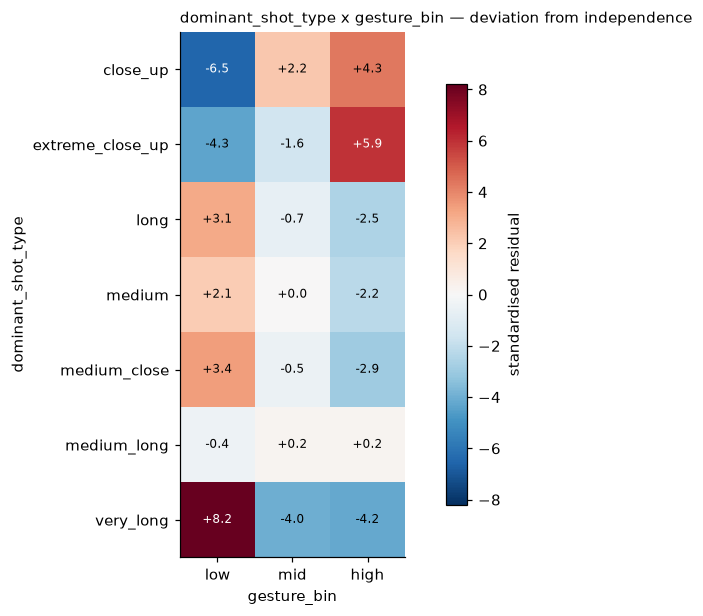


per-video Cramer's V: median 0.261, IQR 0.207-0.325 over 39 videos
A pooled V far above the per-video median would mean the association is between speakers, not within them.


In [9]:
if HAS_DATA and not assoc.empty:
    top = assoc.sort_values("Cramer's V", ascending=False).iloc[0]
    a, b = top["variable A"], top["variable B"]
    sub = cat[[a, b]].dropna()
    tab = pd.crosstab(sub[a], sub[b])
    chi2, pv, dof, v, exp = cramers_v(tab)
    resid = ((tab - exp) / np.sqrt(exp)).round(1)

    print(f"strongest association: {a} x {b}   Cramer's V = {v:.3f}")
    display(pd.concat([(tab.T / tab.sum(axis=1)).T.mul(100).round(1).add_suffix(" %"),
                       resid.add_suffix(" resid")], axis=1))

    fig, ax = plt.subplots(figsize=(1.6 * tab.shape[1] + 3, 0.5 * tab.shape[0] + 2.2))
    lim = np.abs(resid.values).max()
    im = ax.imshow(resid.values, cmap="RdBu_r", vmin=-lim, vmax=lim)
    ax.set_xticks(range(tab.shape[1]), tab.columns)
    ax.set_yticks(range(tab.shape[0]), tab.index)
    ax.set_xlabel(b); ax.set_ylabel(a); ax.grid(False)
    for i in range(tab.shape[0]):
        for j in range(tab.shape[1]):
            ax.text(j, i, f"{resid.values[i, j]:+.1f}", ha="center", va="center",
                    fontsize=8, color="white" if abs(resid.values[i, j]) > lim * 0.6 else "black")
    fig.colorbar(im, ax=ax, shrink=0.8, label="standardised residual")
    ax.set_title(f"{a} x {b} — deviation from independence", loc="left", fontsize=10)
    plt.tight_layout(); plt.show()

    # The honest-n version: does each video show the same association?
    per_video = []
    for jid, g in cat.groupby("job_id"):
        s = g[[a, b]].dropna()
        if len(s) < 40 or s[a].nunique() < 2 or s[b].nunique() < 2:
            continue
        t = pd.crosstab(s[a], s[b])
        if min(t.shape) < 2:
            continue
        per_video.append(cramers_v(t)[3])
    if per_video:
        pv_arr = np.array(per_video)
        print(f"\nper-video Cramer's V: median {np.median(pv_arr):.3f}, "
              f"IQR {np.percentile(pv_arr, 25):.3f}-{np.percentile(pv_arr, 75):.3f} "
              f"over {len(pv_arr)} videos")
        print("A pooled V far above the per-video median would mean the "
              "association is between speakers, not within them.")

## 7. Confound checks — §6's last requirement

> Check for confounds before interpreting correlations: video duration, speaker
> identity, and talk genre (narrative vs. argumentative) can produce spurious
> cross-modal correlations.

Taken one at a time.

**Speaker identity** is handled by section 1's decomposition, and quantified
here as the share of each signal's variance that sits between speakers rather
than within them. A signal that is mostly between-speaker variance is one where
a pooled correlation is really a correlation across people.

**Video duration** is checked directly: if longer talks are systematically
louder or more gestural, duration is a common cause and any gesture-prosody
correlation inherits it.

**Shot scale** is not in §6's list but belongs here, because it is the confound
this project has already been bitten by — the pixel gesture signal correlates
with face size at ~0.47. The normalised signal should not, and the contrast is
shown rather than asserted.

**Talk genre is not recorded anywhere in the pipeline**, so it cannot be
checked. It is the one item of §6 this notebook cannot satisfy. A usable proxy
exists — first-person-singular rate separates personal narrative from
argumentative exposition reasonably well, and the concept table already defines
those forms — but a proxy is not the variable, and labelling genre per talk is
a small annotation job that would settle it properly.

In [10]:
if HAS_DATA:
    # ── variance between vs within speakers ──────────────────────────────
    rows = []
    for col in [GESTURE, PROSODY, "pitch_st", "word_count", "mean_face_bbox_area"]:
        if col not in df.columns:
            continue
        s = df[["job_id", col]].dropna()
        if s.empty:
            continue
        grand = s[col].mean()
        grp = s.groupby("job_id")[col]
        ss_between = (grp.count() * (grp.mean() - grand) ** 2).sum()
        ss_total = ((s[col] - grand) ** 2).sum()
        rows.append({"signal": col,
                     "between-speaker variance": f"{ss_between / ss_total:.1%}",
                     "reading": ("mostly a speaker trait" if ss_between / ss_total > 0.5
                                 else "mostly within-speaker variation")})
    display(pd.DataFrame(rows).set_index("signal"))

    # ── duration as a common cause ───────────────────────────────────────
    per_vid = df.groupby("job_id")[[GESTURE, PROSODY, "word_count"]].mean()
    per_vid = per_vid.join(videos.set_index("job_id").duration_s).dropna()
    rows = []
    for col in [GESTURE, PROSODY, "word_count"]:
        rho = spearmanr(per_vid[col], per_vid.duration_s).statistic
        rows.append({"signal": col, "rho vs video duration": round(rho, 3),
                     "n videos": len(per_vid)})
    display(pd.DataFrame(rows).set_index("signal"))
    print("Near zero means talk length is not a common cause of the coupling above.")

    # ── shot scale: the confound already met once ────────────────────────
    rows = []
    for col in [GESTURE, PIXEL_GESTURE]:
        if col not in df.columns:
            continue
        sub = df[[col, "mean_face_bbox_area"]].dropna()
        rows.append({"gesture signal": col,
                     "units": "shoulder-widths/s" if col == GESTURE else "pixels/s",
                     "rho vs face area": round(spearmanr(sub[col],
                                                         sub.mean_face_bbox_area).statistic, 3),
                     "n": len(sub)})
    display(pd.DataFrame(rows).set_index("gesture signal"))
    print("Closer to zero is less contaminated by how close the camera is. This is "
          "why every figure here uses the normalised signal.")

,between-speaker variance,reading
signal,,
wrist_speed_mean,14.5%,mostly within-speaker variation
mean_intensity_db,24.6%,mostly within-speaker variation
pitch_st,0.9%,mostly within-speaker variation
word_count,19.3%,mostly within-speaker variation
mean_face_bbox_area,16.6%,mostly within-speaker variation


,rho vs video duration,n videos
signal,,
wrist_speed_mean,0.229,39
mean_intensity_db,0.018,39
word_count,-0.274,39


Near zero means talk length is not a common cause of the coupling above.


,units,rho vs face area,n
gesture signal,,,
wrist_speed_mean,shoulder-widths/s,0.322,5558
mean_wrist_velocity,pixels/s,0.469,5635


Closer to zero is less contaminated by how close the camera is. This is why every figure here uses the normalised signal.


## 8. Multimodal timeline for one excerpt

The figure that speaks to a CDA audience. For a chosen 60 seconds it stacks:

* **dense wrist speed** (~10 Hz, from `pose_keyframes`), in **shoulder-widths per
  second** — not pixels, so it is comparable across shots and videos
  (`_corpus.wrist_speed_series`)
* **spoken words**, at their real timestamps
* **window-level intensity**, drawn as steps — a reminder that prosody is only
  stored at 5s resolution
* **shot type and scene cuts**

This does not prove coupling statistically; it shows it (or fails to) in a form
a reader can inspect, which is the appropriate register for a case study.

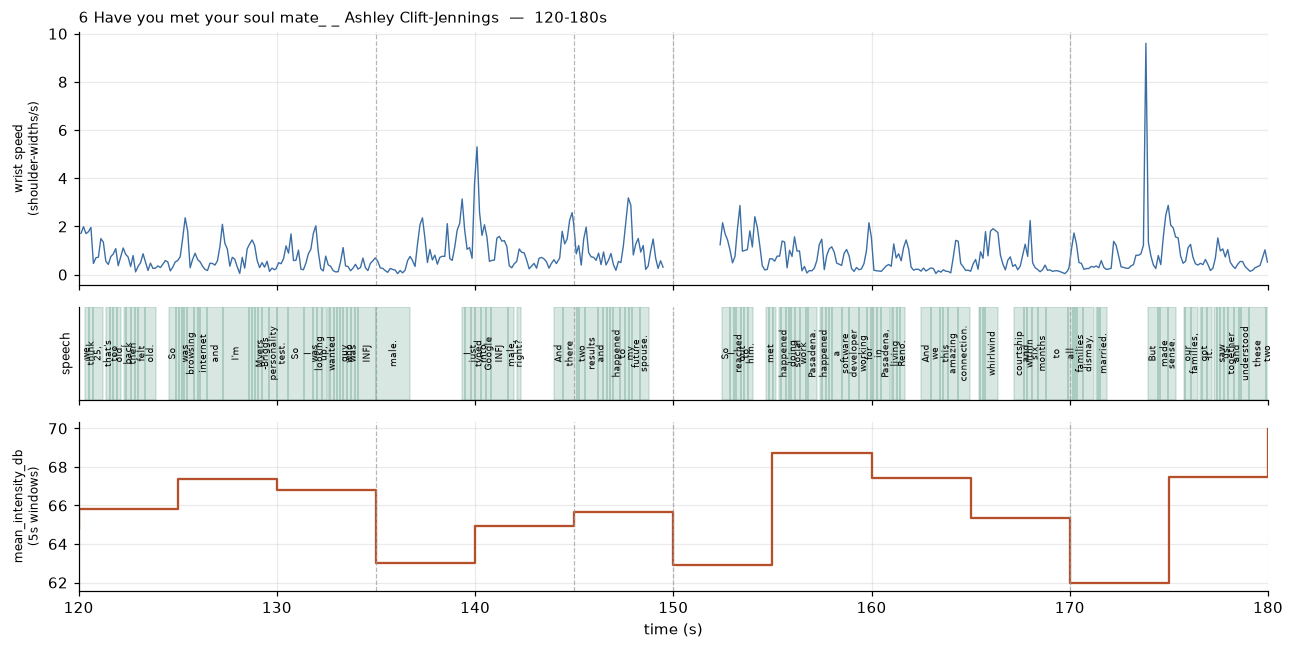

dense gesture samples in view: 459  (7.7 Hz) | words: 151 | dashed lines mark windows containing a scene cut


In [11]:
JOB = None          # None -> first video in the corpus
T0, T1 = 120, 180   # seconds

if HAS_DATA:
    job = JOB or videos.job_id.iloc[5]
    label = videos.loc[videos.job_id == job, "label"].iloc[0]
    speed = C.wrist_speed_series(CORPUS, job)
    words = C.word_tokens(CORPUS, job)
    wins = df[df.job_id == job].sort_values("start_s")

    seg = speed[(speed.ts >= T0) & (speed.ts <= T1)]
    wseg = words[(words.start_s >= T0) & (words.start_s <= T1)]
    win_seg = wins[(wins.start_s >= T0 - WINDOW_S) & (wins.start_s <= T1)]

    fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True,
                             gridspec_kw={"height_ratios": [3, 1.1, 2]})

    axes[0].plot(seg.ts, seg.speed, lw=0.9, color="#3b6ea5")
    axes[0].set_ylabel("wrist speed\n(shoulder-widths/s)", fontsize=8)
    axes[0].set_title(f"{label[:60]}  —  {T0}-{T1}s", loc="left", fontsize=10)

    axes[1].set_ylim(0, 1); axes[1].set_yticks([])
    for _, w in wseg.iterrows():
        axes[1].axvspan(w.start_s, w.end_s, color="#2a7f62", alpha=0.18)
        if w.end_s - w.start_s > 0.18:
            axes[1].text((w.start_s + w.end_s) / 2, 0.5, str(w.word), ha="center",
                         va="center", fontsize=6, rotation=90)
    axes[1].set_ylabel("speech", fontsize=8)

    axes[2].step(win_seg.start_s, win_seg[PROSODY], where="post", color="#b5502a")
    axes[2].set_ylabel(f"{PROSODY}\n(5s windows)", fontsize=8)
    axes[2].set_xlabel("time (s)")

    for _, w in win_seg.iterrows():
        if w.get("cut_count", 0):
            for ax in axes:
                ax.axvline(w.start_s, color="0.6", lw=0.8, ls="--", alpha=0.7)

    for ax in axes:
        ax.set_xlim(T0, T1)
    plt.tight_layout(); plt.show()
    print(f"dense gesture samples in view: {len(seg)}  ({len(seg) / max(1e-9, T1 - T0):.1f} Hz)"
          f" | words: {len(wseg)} | dashed lines mark windows containing a scene cut")

## 9. Sub-second cross-correlation — the figure that settles it

This section was blocked. `ProsodyWorker` computed f0 and intensity densely and
threw them away after aggregating to the 5-second window, so the only prosody
available was already averaged over roughly fifteen words — an order of
magnitude coarser than the phenomenon.

`scripts/backfill_dense_prosody.py` now stores those contours at a 10 ms hop,
reconciled against the window means (r = 0.99). **All 39 Ted videos are
backfilled**, so the figure runs.

What it does, per video: resample wrist speed and intensity onto a common 10 Hz
grid, cross-correlate over lags of −2 s to +2 s, and build a null band by
circularly shifting one signal — which preserves each signal's own
autocorrelation while destroying the relationship between them. Curves are
averaged across videos with a 95% confidence band.

**How to read it.** A peak above the null band is synchrony. Lag `l`
correlates gesture at time *t* with intensity at *t+l*, so a peak at **positive**
lag means gesture happens first — the direction the gesture-speech literature
predicts, with the stroke landing on or slightly before the prosodic peak. A
peak at negative lag means the voice leads instead. (The convention was checked
against a synthetic pair with a known offset rather than assumed; getting it
backwards would invert the conclusion.)

A flat line inside the band, at this resolution, would be the first result here
that genuinely argues against coupling — every flat line above it was
explicable by 5-second averaging.

YiXi has only one video backfilled, so this is a Ted figure until the rest are
processed.

2026-09-24 22:00:19.729 | INFO     | core.results_repository:__init__:199 - [repo] 5 MongoDB shards, fill order: multiarth-cluster-1.rx35xvv.mongodb.net, cluster0.axiwkps.mongodb.net, mutliarth-cluster.7lduqij.mongodb.net, multiarth-cluster-1.wwaqwip.mongodb.net, multiarth-cluster-1.kliir9n.mongodb.net


39 of 39 videos had both dense signals


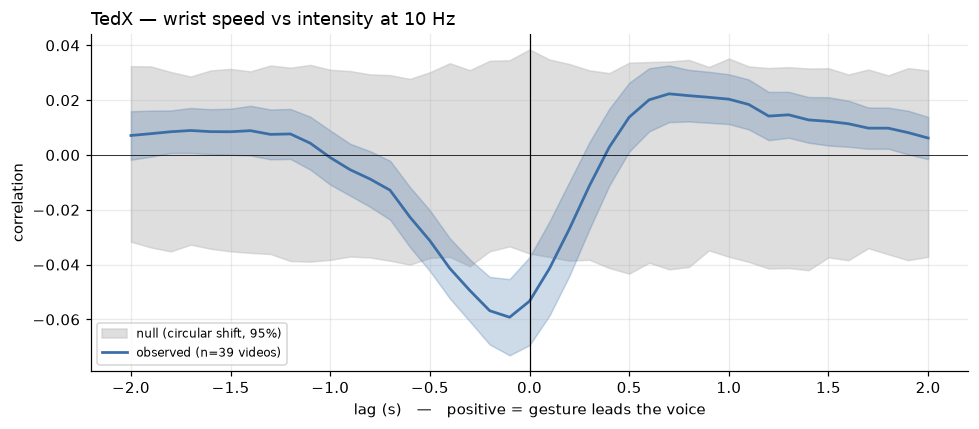

peak |r| = -0.059 at lag -0.10s  ->  voice leads
outside the null band at lags -0.40s to +0.10s (6 of 41 lags)


In [12]:
HZ = 10.0            # common grid for both signals
MAX_LAG_S = 2.0
N_PERM = 200
MIN_S = 120          # skip videos with too little usable overlap


def resampled_pair(corpus, job_id, hz=HZ):
    """Wrist speed and intensity on one grid, or None if either is missing.

    Intensity rather than f0: f0 is NaN wherever Praat found no voicing, which
    is most of the silence between phrases, and interpolating across those gaps
    would invent a signal. Intensity is defined continuously.
    """
    speed = C.wrist_speed_series(corpus, job_id).dropna(subset=["speed"])
    dense = C.dense_prosody(corpus, job_id)
    if speed.empty or dense.empty:
        return None
    lo = max(speed.ts.min(), dense.ts.min())
    hi = min(speed.ts.max(), dense.ts.max())
    if hi - lo < MIN_S:
        return None
    grid = np.arange(lo, hi, 1.0 / hz)
    g = np.interp(grid, speed.ts, speed.speed)
    d = dense.dropna(subset=["intensity_db"])
    if len(d) < 2:
        return None
    p_ = np.interp(grid, d.ts, d.intensity_db)
    z = lambda x: (x - x.mean()) / (x.std() or 1)
    return z(g), z(p_)


def ccf(g, p_, lags):
    out = []
    for l in lags:
        a = g[max(0, -l):len(g) - max(0, l)]
        b = p_[max(0, l):len(p_) - max(0, -l)]
        out.append(np.corrcoef(a, b)[0, 1] if len(a) > 10 else np.nan)
    return np.array(out)


if HAS_DATA:
    lags = np.arange(-int(MAX_LAG_S * HZ), int(MAX_LAG_S * HZ) + 1)
    rng = np.random.default_rng(0)
    obs_all, null_all, used = [], [], []

    for jid in videos.job_id:
        rp = resampled_pair(CORPUS, jid)
        if rp is None:
            continue
        g, p_ = rp
        obs_all.append(ccf(g, p_, lags))
        used.append(jid)
        # Circular shift preserves each signal's autocorrelation and destroys
        # only the cross-relationship — the right null for two smooth series.
        for _ in range(N_PERM // 20):
            shift = rng.integers(int(5 * HZ), len(p_) - int(5 * HZ))
            null_all.append(ccf(g, np.roll(p_, shift), lags))

    print(f"{len(used)} of {len(videos)} videos had both dense signals")

    if obs_all:
        obs = np.vstack(obs_all)
        null = np.vstack(null_all)
        mean = np.nanmean(obs, axis=0)
        sem = np.nanstd(obs, axis=0) / np.sqrt(len(obs))
        lo_n, hi_n = (np.nanpercentile(null, 2.5, axis=0),
                      np.nanpercentile(null, 97.5, axis=0))
        x = lags / HZ

        fig, ax = plt.subplots(figsize=(9, 4))
        ax.fill_between(x, lo_n, hi_n, color="0.75", alpha=0.5,
                        label="null (circular shift, 95%)")
        ax.fill_between(x, mean - 1.96 * sem, mean + 1.96 * sem,
                        color="#3b6ea5", alpha=0.25)
        ax.plot(x, mean, color="#3b6ea5", lw=1.8, label=f"observed (n={len(obs)} videos)")
        ax.axvline(0, color="k", lw=0.8)
        ax.axhline(0, color="k", lw=0.5)
        # Sign convention, verified against a synthetic pair of known offset:
        # lag l correlates gesture(t) with intensity(t+l), so a peak at
        # POSITIVE lag means gesture happens first.
        ax.set_xlabel("lag (s)   —   positive = gesture leads the voice")
        ax.set_ylabel("correlation")
        ax.set_title(f"{CORPUS} — wrist speed vs intensity at {HZ:.0f} Hz", loc="left")
        ax.legend(fontsize=8)
        plt.tight_layout(); plt.show()

        peak = int(np.nanargmax(np.abs(mean)))
        lead = "gesture leads" if x[peak] > 0 else "voice leads" if x[peak] < 0 else "simultaneous"
        outside = (mean > hi_n) | (mean < lo_n)
        print(f"peak |r| = {mean[peak]:+.3f} at lag {x[peak]:+.2f}s  ->  {lead}")
        if outside.any():
            span = x[outside]
            print(f"outside the null band at lags {span.min():+.2f}s to {span.max():+.2f}s "
                  f"({outside.sum()} of {len(x)} lags)")
        else:
            print("nowhere outside the null band — no synchrony detectable even "
                  "at this resolution, which the 5s figures could not have shown.")

## What to conclude, and what not to

* A flat line in sections 2 and 4 does **not** show the modalities are
  independent. It shows they do not covary *in magnitude* at *5-second*
  resolution — which is compatible with tight coordination at 0.2-2s.
* Section 1 tells you whether any speaker-level structure is hiding in the null.
  If the per-video dots cluster at zero, the pooled zero is honest.
* Section 3 is the one most likely to produce a positive, publishable result
  from stored data: intermittent coupling that averages away.
* Section 6 answers a different question from the continuous figures, and a
  more CDA-shaped one: whether production choices track delivery choices. Read
  Cramér's V against the per-video median — a pooled association far above it
  is between speakers, not within them.
* Section 7 says which confounds are ruled out. Talk genre is the one item of
  §6 that cannot be checked, because it is recorded nowhere; labelling it per
  talk is a small annotation job.
* Section 8 is the right figure for a qualitative argument; it should sit
  alongside close analysis, not replace it.
* Section 9 is now the decisive one. A flat line *there* is evidence of absence
  in a way that a flat line in sections 2-5 never was.

**Still unaddressed by any figure here:** gesture *form*. Deictic, iconic,
metaphoric and beat gestures make meaning in different ways, and the pipeline
records only magnitude. No correlation among these columns can speak to
co-expressivity; that needs a gesture typology, which today means annotation.